## 1. Import Required Libraries


In [ ]:
# Core libraries
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42


## 2. Load Dataset


In [ ]:
# For Google Colab users only. If running locally, this block will be skipped safely.
try:
    from google.colab import drive
    drive.mount('/content/drive/')
except Exception:
    print('Not running in Google Colab, or Drive is already mounted.')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# Update this path if your dataset is stored somewhere else.
DATA_PATH = '/content/drive/MyDrive/Datasets/ML_Learn/Telecom_Customer_Churn_Prediction/Telecom_Customer_Churn_Prediction.csv'

# Fallback: if the CSV is in the same folder as this notebook.
LOCAL_PATH = 'Telecom_Customer_Churn_Prediction.csv'

if os.path.exists(DATA_PATH):
    raw_data = pd.read_csv(DATA_PATH)
elif os.path.exists(LOCAL_PATH):
    raw_data = pd.read_csv(LOCAL_PATH)
else:
    raise FileNotFoundError('Dataset not found. Update DATA_PATH or place the CSV in the notebook folder.')

print('Dataset shape:', raw_data.shape)
raw_data.head()


Dataset shape: (51047, 58)


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


## 3. Basic Data Checks


In [ ]:
print('Columns:')
print(raw_data.columns.tolist())

print('Data types:')
print(raw_data.dtypes)

print('Missing values:')
missing = raw_data.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print('Duplicate rows:', raw_data.duplicated().sum())


Columns:
['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser', 'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMotorcycle', 'AdjustmentsToCreditRating', 'HandsetPrice', 'MadeCallToRetention

Churn
No     36336
Yes    14711
Name: count, dtype: int64
Target percentage:
Churn
No     71.18146
Yes    28.81854
Name: proportion, dtype: float64


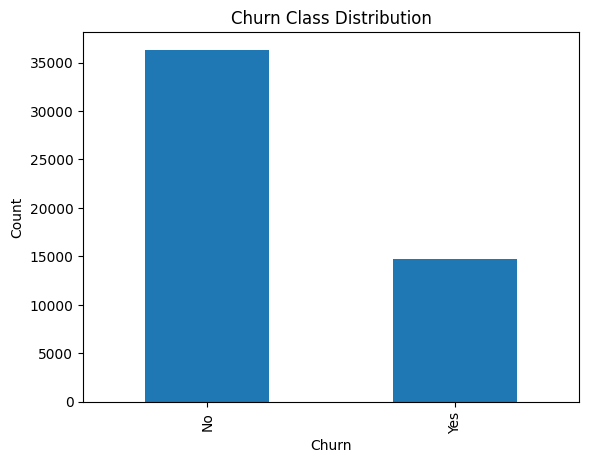

In [ ]:
# Check target distribution before modelling
print(raw_data['Churn'].value_counts(dropna=False))
print('Target percentage:')
print(raw_data['Churn'].value_counts(normalize=True, dropna=False) * 100)

raw_data['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


## 4. Encode Target and Remove ID Columns


In [ ]:
data = raw_data.copy()

# Encode target column
if data['Churn'].dtype == 'object':
    data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Drop rows where target could not be mapped
before = data.shape[0]
data = data.dropna(subset=['Churn'])
data['Churn'] = data['Churn'].astype(int)
print('Rows removed due to missing/invalid target:', before - data.shape[0])

# Drop obvious identifier columns if present
id_cols = [col for col in ['CustomerID', 'customerID', 'customer_id', 'CustomerId'] if col in data.columns]
print('ID columns removed:', id_cols)

data = data.drop(columns=id_cols)


Rows removed due to missing/invalid target: 0
ID columns removed: ['CustomerID']


## 5. Row-Level Feature Engineering

These features are safe to create before splitting because they use only values from the same row, not future information or dataset-level statistics.


In [ ]:
def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def add_churn_features(df):
    df = df.copy()
    cols = df.columns
    eps = 1e-6

    # Revenue per minute: useful when both revenue and usage exist
    if {'MonthlyRevenue', 'MonthlyMinutes'}.issubset(cols):
        df['RevenuePerMinute'] = df['MonthlyRevenue'] / (df['MonthlyMinutes'] + eps)

    # Overage pressure: high overage may indicate billing dissatisfaction
    if {'OverageMinutes', 'MonthlyMinutes'}.issubset(cols):
        df['OverageMinuteRatio'] = df['OverageMinutes'] / (df['MonthlyMinutes'] + eps)

    # Roaming intensity
    if {'RoamingCalls', 'MonthlyMinutes'}.issubset(cols):
        df['RoamingCallRatio'] = df['RoamingCalls'] / (df['MonthlyMinutes'] + eps)

    # Customer care dependency
    if {'CustomerCareCalls', 'MonthlyMinutes'}.issubset(cols):
        df['CustomerCarePerMinute'] = df['CustomerCareCalls'] / (df['MonthlyMinutes'] + eps)

    # Call quality issues
    call_issue_cols = [c for c in ['DroppedCalls', 'BlockedCalls', 'UnansweredCalls'] if c in cols]
    if call_issue_cols:
        df['TotalCallIssues'] = df[call_issue_cols].sum(axis=1)

    if {'TotalCallIssues', 'MonthlyMinutes'}.issubset(df.columns):
        df['CallIssuePerMinute'] = df['TotalCallIssues'] / (df['MonthlyMinutes'] + eps)

    # Change direction flags: useful for churn behaviour
    if 'PercChangeMinutes' in cols:
        df['UsageDropFlag'] = (df['PercChangeMinutes'] < 0).astype(int)

    if 'PercChangeRevenues' in cols:
        df['RevenueDropFlag'] = (df['PercChangeRevenues'] < 0).astype(int)

    # Charge pressure relative to revenue
    if {'TotalRecurringCharge', 'MonthlyRevenue'}.issubset(cols):
        df['RecurringChargeRevenueRatio'] = df['TotalRecurringCharge'] / (df['MonthlyRevenue'] + eps)

    # Replace infinite values generated by division
    df = df.replace([np.inf, -np.inf], np.nan)
    return df


data_fe = add_churn_features(data)
print('Original columns:', data.shape[1])
print('Columns after feature engineering:', data_fe.shape[1])
print('New columns added:', sorted(set(data_fe.columns) - set(data.columns)))


Original columns: 57
Columns after feature engineering: 66
New columns added: ['CallIssuePerMinute', 'CustomerCarePerMinute', 'OverageMinuteRatio', 'RecurringChargeRevenueRatio', 'RevenueDropFlag', 'RevenuePerMinute', 'RoamingCallRatio', 'TotalCallIssues', 'UsageDropFlag']


## 6. Train / Validation / Test Split

The split is: 70% train, 15% validation, 15% test. Validation is used for threshold selection. Test is kept clean until the final evaluation.


In [ ]:
X = data_fe.drop(columns=['Churn'])
y = data_fe['Churn']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y
)

# 0.1765 of 85% is approximately 15% of total data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1765,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print('Train shape      :', X_train.shape)
print('Validation shape :', X_val.shape)
print('Test shape       :', X_test.shape)

print('Train target distribution:')
print(y_train.value_counts(normalize=True))
print('Validation target distribution:')
print(y_val.value_counts(normalize=True))
print('Test target distribution:')
print(y_test.value_counts(normalize=True))


Train shape      : (35730, 65)
Validation shape : (7659, 65)
Test shape       : (7658, 65)
Train target distribution:
Churn
0    0.711811
1    0.288189
Name: proportion, dtype: float64
Validation target distribution:
Churn
0    0.711842
1    0.288158
Name: proportion, dtype: float64
Test target distribution:
Churn
0    0.711805
1    0.288195
Name: proportion, dtype: float64


## 7. Preprocessing Pipeline

Imputation, scaling, and encoding are fitted only on training data through the pipeline. This prevents leakage.


In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numerical columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# sparse_output=False works in newer sklearn. If older sklearn fails, replace with sparse=False.
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])


Numerical columns: 43
Categorical columns: 22


## 8. Helper Functions for Evaluation and Threshold Tuning


In [ ]:
def evaluate_predictions(y_true, y_proba, threshold=0.5, label='Model'):
    y_pred = (y_proba >= threshold).astype(int)
    results = {
        'Model': label,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_proba),
        'PR_AUC': average_precision_score(y_true, y_proba)
    }
    return results


def find_best_threshold(y_true, y_proba, metric='f1'):
    thresholds = np.arange(0.10, 0.91, 0.01)
    rows = []

    for threshold in thresholds:
        row = evaluate_predictions(y_true, y_proba, threshold=threshold, label='threshold_search')
        rows.append(row)

    threshold_df = pd.DataFrame(rows)
    metric_map = {
        'f1': 'F1',
        'recall': 'Recall',
        'precision': 'Precision'
    }
    sort_col = metric_map.get(metric, 'F1')
    best_row = threshold_df.sort_values(sort_col, ascending=False).iloc[0]
    return float(best_row['Threshold']), threshold_df


def print_detailed_report(y_true, y_proba, threshold, title):
    y_pred = (y_proba >= threshold).astype(int)
    print(f'========== {title} ==========')
    print(f'Threshold : {threshold:.2f}')
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'ROC-AUC   : {roc_auc_score(y_true, y_proba):.4f}')
    print(f'PR-AUC    : {average_precision_score(y_true, y_proba):.4f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    print('Classification Report:')
    print(classification_report(y_true, y_pred, zero_division=0))


## 9. Baseline Logistic Regression


In [ ]:
log_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

log_baseline.fit(X_train, y_train)
log_val_proba = log_baseline.predict_proba(X_val)[:, 1]

log_best_threshold, log_threshold_df = find_best_threshold(y_val, log_val_proba, metric='f1')

print_detailed_report(y_val, log_val_proba, 0.50, 'Logistic Regression Validation - Default Threshold')
print_detailed_report(y_val, log_val_proba, log_best_threshold, 'Logistic Regression Validation - Tuned Threshold')


========== Logistic Regression Validation - Default Threshold ==========
Threshold : 0.50
Accuracy  : 0.5922
Precision : 0.3663
Recall    : 0.5686
F1 Score  : 0.4456
ROC-AUC   : 0.6166
PR-AUC    : 0.3772
Confusion Matrix:
[[3281 2171]
 [ 952 1255]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.60      0.68      5452
           1       0.37      0.57      0.45      2207

    accuracy                           0.59      7659
   macro avg       0.57      0.59      0.56      7659
weighted avg       0.66      0.59      0.61      7659

========== Logistic Regression Validation - Tuned Threshold ==========
Threshold : 0.40
Accuracy  : 0.4499
Precision : 0.3251
Recall    : 0.8446
F1 Score  : 0.4695
ROC-AUC   : 0.6166
PR-AUC    : 0.3772
Confusion Matrix:
[[1582 3870]
 [ 343 1864]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.29      0.43      5452
           1       0.3

## 10. Tuned Logistic Regression


In [ ]:
log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

log_param_grid = {
    'model__C': np.logspace(-3, 2, 12),
    'model__solver': ['liblinear', 'lbfgs']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

log_search = RandomizedSearchCV(
    estimator=log_pipeline,
    param_distributions=log_param_grid,
    n_iter=12,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

log_search.fit(X_train, y_train)
print('Best Logistic Regression parameters:')
print(log_search.best_params_)
print('Best CV F1:', log_search.best_score_)

log_tuned = log_search.best_estimator_
log_tuned_val_proba = log_tuned.predict_proba(X_val)[:, 1]
log_tuned_threshold, log_tuned_threshold_df = find_best_threshold(y_val, log_tuned_val_proba, metric='f1')

print_detailed_report(y_val, log_tuned_val_proba, log_tuned_threshold, 'Tuned Logistic Regression Validation')


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Logistic Regression parameters:
{'model__solver': 'liblinear', 'model__C': np.float64(0.002848035868435802)}
Best CV F1: 0.452001441034558
========== Tuned Logistic Regression Validation ==========
Threshold : 0.44
Accuracy  : 0.4856
Precision : 0.3368
Recall    : 0.8106
F1 Score  : 0.4759
ROC-AUC   : 0.6277
PR-AUC    : 0.3888
Confusion Matrix:
[[1930 3522]
 [ 418 1789]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.35      0.49      5452
           1       0.34      0.81      0.48      2207

    accuracy                           0.49      7659
   macro avg       0.58      0.58      0.49      7659
weighted avg       0.68      0.49      0.49      7659



## 11. Baseline Random Forest


In [ ]:
rf_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_baseline.fit(X_train, y_train)
rf_val_proba = rf_baseline.predict_proba(X_val)[:, 1]
rf_best_threshold, rf_threshold_df = find_best_threshold(y_val, rf_val_proba, metric='f1')

print_detailed_report(y_val, rf_val_proba, 0.50, 'Random Forest Validation - Default Threshold')
print_detailed_report(y_val, rf_val_proba, rf_best_threshold, 'Random Forest Validation - Tuned Threshold')


========== Random Forest Validation - Default Threshold ==========
Threshold : 0.50
Accuracy  : 0.7145
Precision : 0.5538
Recall    : 0.0467
F1 Score  : 0.0861
ROC-AUC   : 0.6538
PR-AUC    : 0.4190
Confusion Matrix:
[[5369   83]
 [2104  103]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.98      0.83      5452
           1       0.55      0.05      0.09      2207

    accuracy                           0.71      7659
   macro avg       0.64      0.52      0.46      7659
weighted avg       0.67      0.71      0.62      7659

========== Random Forest Validation - Tuned Threshold ==========
Threshold : 0.26
Accuracy  : 0.5451
Precision : 0.3615
Recall    : 0.7553
F1 Score  : 0.4890
ROC-AUC   : 0.6538
PR-AUC    : 0.4190
Confusion Matrix:
[[2508 2944]
 [ 540 1667]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.46      0.59      5452
           1       0.36      0.76 

## 12. Tuned Random Forest


In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_param_grid_fast = {
    'model__n_estimators': [150, 250],
    'model__max_depth': [8, 12, None],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [2, 5],
    'model__max_features': ['sqrt']
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid_fast,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)
print('Best Random Forest parameters:')
print(rf_search.best_params_)
print('Best CV F1:', rf_search.best_score_)

rf_tuned = rf_search.best_estimator_
rf_tuned_val_proba = rf_tuned.predict_proba(X_val)[:, 1]
rf_tuned_threshold, rf_tuned_threshold_df = find_best_threshold(y_val, rf_tuned_val_proba, metric='f1')

print_detailed_report(y_val, rf_tuned_val_proba, rf_tuned_threshold, 'Tuned Random Forest Validation')


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest parameters:
{'model__n_estimators': 250, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 8}
Best CV F1: 0.46533181283931935
========== Tuned Random Forest Validation ==========
Threshold : 0.45
Accuracy  : 0.4640
Precision : 0.3350
Recall    : 0.8731
F1 Score  : 0.4842
ROC-AUC   : 0.6424
PR-AUC    : 0.3998
Confusion Matrix:
[[1627 3825]
 [ 280 1927]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.30      0.44      5452
           1       0.34      0.87      0.48      2207

    accuracy                           0.46      7659
   macro avg       0.59      0.59      0.46      7659
weighted avg       0.70      0.46      0.45      7659



## 13. Validation Comparison


In [ ]:
validation_results = []
validation_results.append(evaluate_predictions(y_val, log_val_proba, 0.50, 'Logistic Baseline - 0.50'))
validation_results.append(evaluate_predictions(y_val, log_val_proba, log_best_threshold, 'Logistic Baseline - Tuned Threshold'))
validation_results.append(evaluate_predictions(y_val, log_tuned_val_proba, log_tuned_threshold, 'Logistic Tuned'))
validation_results.append(evaluate_predictions(y_val, rf_val_proba, 0.50, 'Random Forest Baseline - 0.50'))
validation_results.append(evaluate_predictions(y_val, rf_val_proba, rf_best_threshold, 'Random Forest Baseline - Tuned Threshold'))
validation_results.append(evaluate_predictions(y_val, rf_tuned_val_proba, rf_tuned_threshold, 'Random Forest Tuned'))

validation_df = pd.DataFrame(validation_results).sort_values('F1', ascending=False)
validation_df


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
4,Random Forest Baseline - Tuned Threshold,0.26,0.545110,0.361527,0.755324,0.489000,0.653754,0.418964
5,Random Forest Tuned,0.45,0.464029,0.335014,0.873131,0.484232,0.642373,0.399814
2,Logistic Tuned,0.44,0.485573,0.336848,0.810603,0.475924,0.627713,0.388753
1,Logistic Baseline - Tuned Threshold,0.40,0.449928,0.325078,0.844585,0.469462,0.616603,0.377190
0,Logistic Baseline - 0.50,0.50,0.592244,0.366316,0.568645,0.445588,0.616603,0.377190
3,Random Forest Baseline - 0.50,0.50,0.714454,0.553763,0.046670,0.086084,0.653754,0.418964


## 14. Select Best Model from Validation Set


In [ ]:
best_validation_row = validation_df.iloc[0]
best_model_name = best_validation_row['Model']
best_threshold = float(best_validation_row['Threshold'])

if best_model_name == 'Logistic Baseline - 0.50':
    best_model = log_baseline
elif best_model_name == 'Logistic Baseline - Tuned Threshold':
    best_model = log_baseline
elif best_model_name == 'Logistic Tuned':
    best_model = log_tuned
elif best_model_name == 'Random Forest Baseline - 0.50':
    best_model = rf_baseline
elif best_model_name == 'Random Forest Baseline - Tuned Threshold':
    best_model = rf_baseline
else:
    best_model = rf_tuned

print('Best validation model:', best_model_name)
print('Best threshold:', best_threshold)
best_validation_row


Best validation model: Random Forest Baseline - Tuned Threshold
Best threshold: 0.2599999999999999


,4
Model,Random Forest Baseline - Tuned Threshold
Threshold,0.26
Accuracy,0.54511
Precision,0.361527
Recall,0.755324
F1,0.489
ROC_AUC,0.653754
PR_AUC,0.418964


## 15. Final Test Evaluation

This is the clean final score. Do not repeatedly tune after seeing this result.


In [ ]:
best_test_proba = best_model.predict_proba(X_test)[:, 1]
print_detailed_report(y_test, best_test_proba, best_threshold, f'FINAL TEST RESULT - {best_model_name}')


========== FINAL TEST RESULT - Random Forest Baseline - Tuned Threshold ==========
Threshold : 0.26
Accuracy  : 0.5458
Precision : 0.3612
Recall    : 0.7494
F1 Score  : 0.4875
ROC-AUC   : 0.6564
PR-AUC    : 0.4283
Confusion Matrix:
[[2526 2925]
 [ 553 1654]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.46      0.59      5451
           1       0.36      0.75      0.49      2207

    accuracy                           0.55      7658
   macro avg       0.59      0.61      0.54      7658
weighted avg       0.69      0.55      0.56      7658



## 16. Test Comparison for All Main Models


In [ ]:
test_results = []

test_results.append(evaluate_predictions(y_test, log_baseline.predict_proba(X_test)[:, 1], log_best_threshold, 'Logistic Baseline'))
test_results.append(evaluate_predictions(y_test, log_tuned.predict_proba(X_test)[:, 1], log_tuned_threshold, 'Logistic Tuned'))
test_results.append(evaluate_predictions(y_test, rf_baseline.predict_proba(X_test)[:, 1], rf_best_threshold, 'Random Forest Baseline'))
test_results.append(evaluate_predictions(y_test, rf_tuned.predict_proba(X_test)[:, 1], rf_tuned_threshold, 'Random Forest Tuned'))

test_df = pd.DataFrame(test_results).sort_values('F1', ascending=False)
test_df


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Random Forest Baseline,0.26,0.545834,0.361214,0.749434,0.487474,0.656356,0.428277
3,Random Forest Tuned,0.45,0.465396,0.334793,0.866334,0.482950,0.641363,0.408667
1,Logistic Tuned,0.44,0.478062,0.331068,0.794744,0.467422,0.619898,0.392365
0,Logistic Baseline,0.40,0.440716,0.318277,0.823743,0.459149,0.613232,0.389173


## 17. Confusion Matrix, ROC Curve, and PR Curve


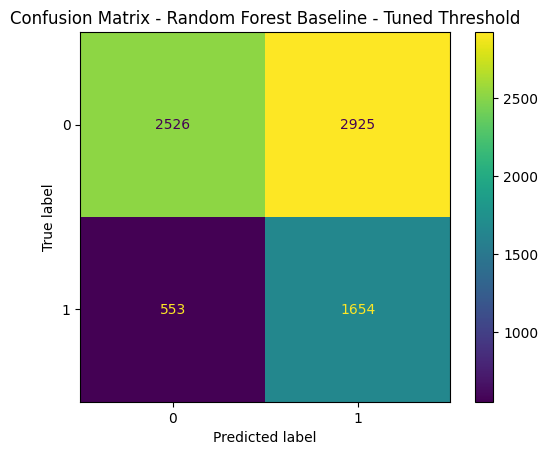

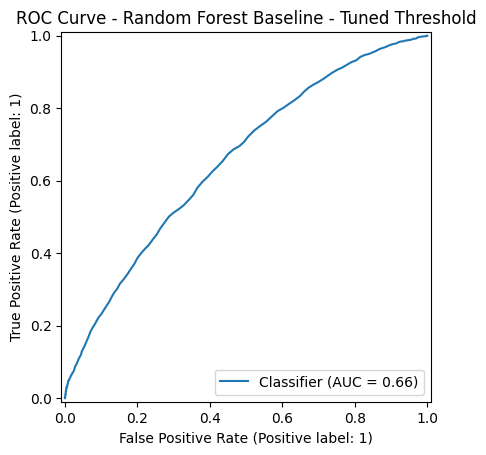

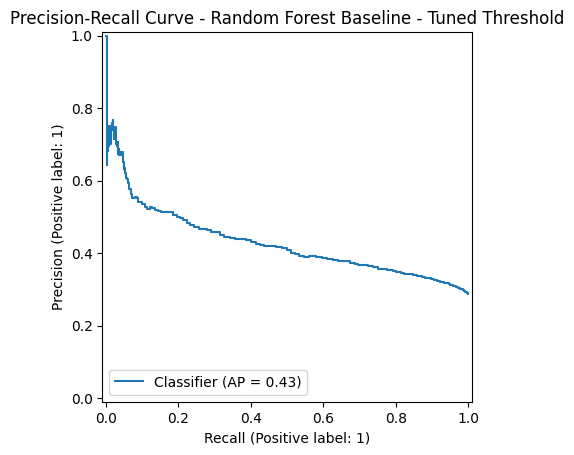

In [ ]:
best_test_pred = (best_test_proba >= best_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, best_test_pred)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

RocCurveDisplay.from_predictions(y_test, best_test_proba)
plt.title(f'ROC Curve - {best_model_name}')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, best_test_proba)
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.show()


## 18. Feature Importance / Coefficients


,Feature,Importance
26,num__CurrentEquipmentDays,0.040360
21,num__MonthsInService,0.033539
6,num__PercChangeMinutes,0.030825
42,num__RecurringChargeRevenueRatio,0.029160
1,num__MonthlyMinutes,0.028806
0,num__MonthlyRevenue,0.027852
7,num__PercChangeRevenues,0.026959
39,num__CallIssuePerMinute,0.025480
16,num__PeakCallsInOut,0.025253
17,num__OffPeakCallsInOut,0.024476


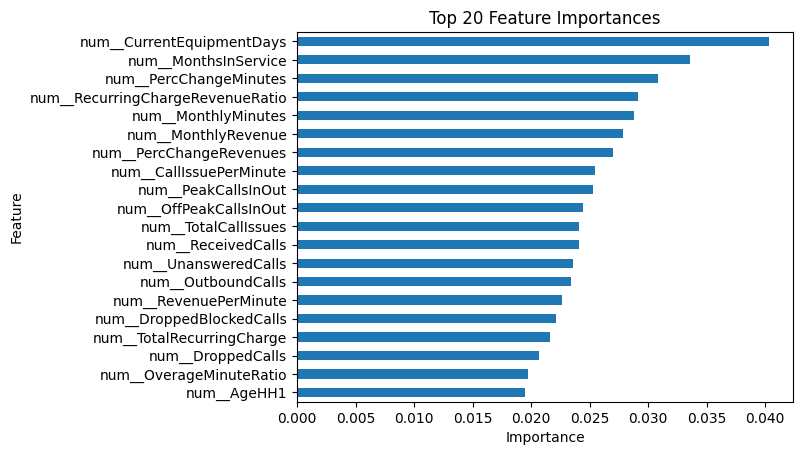

In [ ]:
def get_feature_names_from_pipeline(model_pipeline):
    return model_pipeline.named_steps['preprocessor'].get_feature_names_out()

try:
    feature_names = get_feature_names_from_pipeline(best_model)
    model_step = best_model.named_steps['model']

    if hasattr(model_step, 'feature_importances_'):
        importance_values = model_step.feature_importances_
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance_values
        }).sort_values('Importance', ascending=False)
        display(importance_df.head(20))
        importance_df.head(20).sort_values('Importance').plot(kind='barh', x='Feature', y='Importance', legend=False)
        plt.title('Top 20 Feature Importances')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()

    elif hasattr(model_step, 'coef_'):
        coef_values = model_step.coef_[0]
        coef_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coef_values,
            'AbsCoefficient': np.abs(coef_values)
        }).sort_values('AbsCoefficient', ascending=False)
        display(coef_df.head(20))
        coef_df.head(20).sort_values('Coefficient').plot(kind='barh', x='Feature', y='Coefficient', legend=False)
        plt.title('Top 20 Logistic Regression Coefficients')
        plt.xlabel('Coefficient')
        plt.ylabel('Feature')
        plt.show()
    else:
        print('Selected model does not expose feature importance or coefficients.')
except Exception as e:
    print('Feature importance extraction failed:', e)


## 19. Business Interpretation


Business interpretation:
- Accuracy alone is not enough because churn data is usually imbalanced.
- Recall tells us how many actual churners the model catches.
- Precision tells us how many predicted churners are actually churners.
- F1 balances precision and recall.
- ROC-AUC shows ranking ability across thresholds.
- PR-AUC is useful when the churn class is smaller than the non-churn class.
- Threshold tuning is important because the default 0.50 threshold may miss too many churners.